In [1]:
import torch, os, platform, json, re, hashlib, sqlite3, time
from google.colab import drive
drive.mount("/content/drive")

BASE_DIR = "/content/drive/MyDrive/polisim_alerts_ab/results"
os.makedirs(BASE_DIR, exist_ok=True)
print("BASE_DIR:", BASE_DIR)

Mounted at /content/drive
BASE_DIR: /content/drive/MyDrive/polisim_alerts_ab/results


In [19]:
ALERTS = [
  {
    "alert_id": "a1",
    "title": "Boil Water Advisory",
    "text": "Boil water before drinking or cooking until further notice. Use bottled water if available. Check official updates for status.",
    "required_actions": ["boil water", "use bottled water", "check updates"]
  },
  {
    "alert_id": "a2",
    "title": "Severe Storm Warning",
    "text": "Severe storm approaching. Stay indoors, away from windows. Avoid travel unless necessary. Monitor official alerts.",
    "required_actions": ["stay indoors", "avoid windows", "avoid travel", "monitor alerts"]
  },
  {
    "alert_id": "a3",
    "title": "High Wind Warning",
    "text": "Northeast winds 30 to 45 mph with gusts up to 60 mph expected. High winds may move loose debris, damage property, and cause power outages. Travel could be difficult. People are urged to secure loose objects that could be blown around or damaged by the wind.",
    "required_actions": ["secure loose objects", "prepare for power outages", "use caution while traveling"]

  },
  {
  "alert_id": "a4",
  "title": "Ashfall Advisory",
  "text": "Volcanic ashfall possible across affected areas. Persons with respiratory illnesses should remain indoors to avoid inhaling ash particles. All persons outside should cover their mouth and nose with a mask or cloth. Reduced visibility and minor damage are possible.",
  "required_actions": ["stay indoors if respiratory illness", "cover mouth and nose", "limit outdoor exposure"]
  },
  {
  "alert_id": "a5",
  "title": "Flood Advisory",
  "text": "Recent heavy rain caused flooding in the area. Although the heaviest rain has ended, additional showers are possible. Continue to heed remaining road closures and be aware of lingering flooding impacts.",
  "required_actions": ["avoid flooded roads", "heed road closures", "remain alert for additional rainfall"]
  },
  {
  "alert_id": "a6",
  "title": "Dense Fog Advisory",
  "text": "Dense fog with visibility down to a quarter mile is expected. Low visibility could make driving hazardous. If driving, slow down, use headlights, and leave plenty of distance between vehicles.",
  "required_actions": ["slow down while driving", "use headlights", "increase following distance"]
  },
  {
  "alert_id": "a7",
  "title": "Cold Weather Advisory",
  "text": "Very cold wind chill temperatures are expected, with frostbite possible on exposed skin in as little as 30 minutes. Use caution while outdoors and dress appropriately for the cold. Ensure outdoor animals have adequate shelter, food, and unfrozen water.",
  "required_actions": ["wear warm clothing", "limit time outdoors", "use caution while outside", "provide shelter for animals"]
  },
  {
  "alert_id": "a8",
  "title": "Severe Thunderstorm Warning",
  "text": "A severe thunderstorm with damaging wind gusts is moving through the area. Tornadoes can develop quickly from severe thunderstorms. Move to an interior room on the lowest floor of a sturdy building and be prepared to act quickly if a tornado is spotted.",
  "required_actions": ["move to interior room", "stay on lowest floor", "seek shelter in sturdy building", "monitor storm conditions"]
 },
 {
  "alert_id": "a9",
  "title": "Ice Storm Warning",
  "text": "Significant icing is expected, making roads, bridges, and sidewalks very slippery. Travel is strongly discouraged. If travel is unavoidable, use extreme caution and carry emergency supplies. Prepare for possible power outages.",
  "required_actions": ["avoid travel", "use extreme caution if traveling", "carry emergency supplies", "prepare for power outages"]
 },
 {
  "alert_id": "a10",
  "title": "Freeze Watch",
  "text": "Sub-freezing temperatures are possible, which could damage crops, sensitive vegetation, and outdoor plumbing. Strong winds may also make driving difficult. Take steps now to protect plants, secure outdoor objects, and prepare plumbing for freezing conditions.",
  "required_actions": ["protect tender plants", "secure outdoor objects", "prepare outdoor plumbing", "use caution while driving"]
 },
 {
  "alert_id": "a11",
  "title": "Rip Current Statement",
  "text": "Dangerous rip currents and large breaking waves are expected. Inexperienced swimmers should remain out of the water. Swim near a lifeguard, and if caught in a rip current, relax and float rather than swimming against it.",
  "required_actions": ["stay out of the water if inexperienced", "swim near a lifeguard", "float if caught in a rip current", "do not swim against the current"]
},
{
  "alert_id": "a12",
  "title": "High Surf Advisory",
  "text": "Large breaking waves and dangerous surf conditions are expected along the coast. Swimming and surfing may be hazardous, and rip currents can sweep swimmers into deeper water.",
  "required_actions": ["avoid swimming in rough surf", "stay near lifeguards", "use caution near the shoreline"]
},
{
  "alert_id": "a13",
  "title": "Brisk Wind Advisory",
  "text": "Brisk winds are expected over coastal waters, with increasing wind speeds and reduced visibility at times due to blowing snow. Conditions may be hazardous for marine activities.",
  "required_actions": ["use caution on the water", "secure vessels and equipment", "avoid hazardous marine conditions"]
},
{
  "alert_id": "a14",
  "title": "High Wind Warning",
  "text": "Strong northeast winds with gusts up to 60 mph are expected. High winds may move loose debris, damage property, and cause power outages. Travel could be difficult, especially in exposed areas.",
  "required_actions": ["secure loose objects", "prepare for power outages", "use caution while traveling"]
},
{
  "alert_id": "a15",
  "title": "Small Craft Advisory",
  "text": "Hazardous marine conditions are expected with strong winds and elevated seas. Conditions will be dangerous for small vessels, especially for inexperienced mariners.",
  "required_actions": ["avoid hazardous marine conditions", "delay travel for small vessels", "use caution on the water"]
},
{
  "alert_id": "a16",
  "title": "Gale Warning",
  "text": "Strong gale-force winds are expected over coastal waters, producing very hazardous marine conditions. High winds and reduced visibility may make navigation dangerous, especially for smaller vessels.",
  "required_actions": ["avoid hazardous marine conditions", "delay marine travel", "secure vessels and equipment"]
},
{
  "alert_id": "a17",
  "title": "Heavy Freezing Spray Advisory",
  "text": "Moderate freezing spray and strong winds are creating hazardous marine conditions. Ice accumulation on vessels may affect stability, damage equipment, and reduce visibility, making navigation dangerous.",
  "required_actions": ["remain in port or seek safe harbor", "prepare for ice accumulation on vessels", "secure lifesaving and vessel equipment"]
}]

def variants_from_alert(alert_text):
    # A: original
    A = alert_text.strip()

    # B: action-first bullets (rule-based)
    # (Very simple; you can improve this once your pipeline works.)
    B = (
        "DO THIS NOW:\n"
        "- Follow the safety actions listed below.\n"
        "- If you are unsure, monitor official updates.\n\n"
        "ALERT DETAILS:\n" + A
    )

    # C: plain language rewrite (light rule-based placeholder)
    C = (
        "Important safety message:\n"
        + re.sub(r"\bmonitor\b", "check", A, flags=re.IGNORECASE)
        .replace("unless necessary", "if you can avoid it")
    )

    # D: constraint-aware addendum (generic)
    D = (
        A
        + "\n\nIf you cannot do the main action (e.g., cannot travel or do not have supplies), "
          "stay as safe as possible where you are and keep checking official updates."
    )

    return {"A_control": A, "B_action_first": B, "C_plain": C, "D_constraint": D}


In [2]:
import json, re, math, numpy as np, pandas as pd
import matplotlib.pyplot as plt

RESULTS_PATH = "/content/drive/MyDrive/polisim_alerts_ab/results/results_v2.parquet"
df = pd.read_parquet(RESULTS_PATH).copy()
print("Loaded:", df.shape)
display(df.head())

Loaded: (5440, 19)


,alert_id,alert_title,variant_id,agent_id,english,mobility,trust,time_pressure,household,retry_count,model,parse_success,raw_output,parsed_json,raw_json,action_recall,confused,compliance_intent,action_clarity
0,a1,Boil Water Advisory,A_control,u0,low,no_car,low,low,solo,0,mistralai/Mistral-7B-Instruct-v0.3,True,"{\n ""actions"": [""Boil water before drinking o...","{""actions"": [""Boil water before drinking or co...","{""actions"": [""Boil water before drinking or co...",0.666667,True,0.5,1.0
1,a1,Boil Water Advisory,B_action_first,u0,low,no_car,low,low,solo,0,mistralai/Mistral-7B-Instruct-v0.3,True,"{\n ""actions"": [""Boil water before drinking o...","{""actions"": [""Boil water before drinking or co...","{""actions"": [""Boil water before drinking or co...",0.666667,True,0.8,1.0
2,a1,Boil Water Advisory,C_plain,u0,low,no_car,low,low,solo,0,mistralai/Mistral-7B-Instruct-v0.3,True,"{\n ""actions"": [""boil water before drinking o...","{""actions"": [""boil water before drinking or co...","{""actions"": [""boil water before drinking or co...",0.666667,True,0.5,1.0
3,a1,Boil Water Advisory,D_constraint,u0,low,no_car,low,low,solo,0,mistralai/Mistral-7B-Instruct-v0.3,True,"{\n ""actions"": [""Boil water before drinking o...","{""actions"": [""Boil water before drinking or co...","{""actions"": [""Boil water before drinking or co...",0.666667,True,0.5,1.0
4,a1,Boil Water Advisory,A_control,u1,low,no_car,low,high,solo,0,mistralai/Mistral-7B-Instruct-v0.3,True,"{\n ""actions"": [""Boil water before drinking o...","{""actions"": [""Boil water before drinking or co...","{""actions"": [""Boil water before drinking or co...",0.666667,True,0.5,1.0


In [20]:
# 1) load results
df = pd.read_parquet(RESULTS_PATH)

# 2) build (alert_id, variant_id) -> variant_text table
rows = []
for a in ALERTS:
    vmap = variants_from_alert(a["text"])
    for vid, vtxt in vmap.items():
        rows.append({"alert_id": a["alert_id"], "variant_id": vid, "variant_text": vtxt})

variant_text_df = pd.DataFrame(rows)

# 3) merge + save
df2 = df.merge(variant_text_df, on=["alert_id", "variant_id"], how="left")

print("Missing variant_text:", df2["variant_text"].isna().mean())
#df2.to_parquet(RESULTS_PATH, index=False)


Missing variant_text: 0.0


In [23]:
df = df2.copy()

In [3]:
JSON_COL_CANDIDATES = ["parsed_json", "raw_json", "json"]
json_col = next((c for c in JSON_COL_CANDIDATES if c in df.columns), None)
print("Using JSON column:", json_col)

def safe_load_json(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return None
        try:
            return json.loads(x)
        except Exception:
            return None
    return None

Using JSON column: parsed_json


In [4]:
df["parsed"] = df[json_col].apply(safe_load_json) if json_col else None
df["parse_success"] = df["parsed"].notna()

# Extract fields from parsed json (if present)
def jget(d, k, default=None):
    return d.get(k, default) if isinstance(d, dict) else default

df["actions_list"] = df["parsed"].apply(lambda d: jget(d, "actions", []))
df["confusion_reason"] = df["parsed"].apply(lambda d: jget(d, "confusion_reason", ""))
df["needs_info"] = df["parsed"].apply(lambda d: jget(d, "needs_info", []))
df["would_share"] = df["parsed"].apply(lambda d: jget(d, "would_share", None))

# If your score columns exist already, keep them; otherwise compute basic defaults
for col in ["action_recall", "confused", "compliance_intent", "action_clarity"]:
    if col not in df.columns:
        df[col] = np.nan

# Ensure numeric
for col in ["action_recall", "compliance_intent", "action_clarity"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Ensure confused is boolean-like
if df["confused"].dtype != bool:
    # if it's None/NaN, keep NaN; else cast
    df["confused"] = df["confused"].map(lambda x: x if isinstance(x, bool) else (np.nan if pd.isna(x) else bool(x)))


In [5]:
# =========================
# 1) Parse/validity diagnostics tables
# =========================
diag = df.groupby("variant_id").agg(
    n=("agent_id", "count"),
    parse_success_rate=("parse_success", "mean"),
    mean_retry=("retry_count", "mean") if "retry_count" in df.columns else ("parse_success", "mean"),
    empty_actions_rate=("actions_list", lambda s: np.mean([isinstance(a, list) and len(a)==0 for a in s])),
).reset_index().sort_values("parse_success_rate")

print("\nParse diagnostics by variant:")
display(diag)

# Optional: diagnostics by subgroup too (english/mobility/trust)
subgroup_cols = [c for c in ["english", "mobility", "trust"] if c in df.columns]
if subgroup_cols:
    diag_sub = df.groupby(subgroup_cols + ["variant_id"]).agg(
        n=("agent_id", "count"),
        parse_success_rate=("parse_success", "mean"),
        empty_actions_rate=("actions_list", lambda s: np.mean([isinstance(a, list) and len(a)==0 for a in s])),
    ).reset_index()
    print("\nParse diagnostics by subgroup:")
    display(diag_sub.head(20))


Parse diagnostics by variant:


,variant_id,n,parse_success_rate,mean_retry,empty_actions_rate
0,A_control,1360,1.0,0.000000,0.0
1,B_action_first,1360,1.0,0.001471,0.0
2,C_plain,1360,1.0,0.000000,0.0
3,D_constraint,1360,1.0,0.000000,0.0



Parse diagnostics by subgroup:


,english,mobility,trust,variant_id,n,parse_success_rate,empty_actions_rate
0,high,car,high,A_control,170,1.0,0.0
1,high,car,high,B_action_first,170,1.0,0.0
2,high,car,high,C_plain,170,1.0,0.0
3,high,car,high,D_constraint,170,1.0,0.0
4,high,car,low,A_control,170,1.0,0.0
5,high,car,low,B_action_first,170,1.0,0.0
6,high,car,low,C_plain,170,1.0,0.0
7,high,car,low,D_constraint,170,1.0,0.0
8,high,no_car,high,A_control,170,1.0,0.0
9,high,no_car,high,B_action_first,170,1.0,0.0


In [6]:
# =========================
# 2) Overall performance tables
# =========================
perf = df.groupby("variant_id").agg(
    n=("agent_id", "count"),
    mean_recall=("action_recall", "mean"),
    mean_confused=("confused", "mean"),
    mean_compliance=("compliance_intent", "mean"),
    mean_clarity=("action_clarity", "mean"),
    parse_success_rate=("parse_success", "mean"),
).reset_index().sort_values("mean_recall", ascending=False)

print("\nOverall performance by variant:")
display(perf)

# Subgroup performance
if subgroup_cols:
    perf_sub = df.groupby(subgroup_cols + ["variant_id"]).agg(
        n=("agent_id", "count"),
        mean_recall=("action_recall", "mean"),
        mean_confused=("confused", "mean"),
        mean_compliance=("compliance_intent", "mean"),
        parse_success_rate=("parse_success", "mean"),
    ).reset_index()
    print("\nSubgroup performance (first rows):")
    display(perf_sub.head(30))


Overall performance by variant:


,variant_id,n,mean_recall,mean_confused,mean_compliance,mean_clarity,parse_success_rate
1,B_action_first,1360,0.227328,0.197794,0.918897,0.963787,1.0
0,A_control,1360,0.200613,0.191912,0.845625,0.934081,1.0
2,C_plain,1360,0.194914,0.194853,0.854301,0.936360,1.0
3,D_constraint,1360,0.187929,0.175000,0.870257,0.933934,1.0



Subgroup performance (first rows):


,english,mobility,trust,variant_id,n,mean_recall,mean_confused,mean_compliance,parse_success_rate
0,high,car,high,A_control,170,0.220588,0.000000,0.940882,1.0
1,high,car,high,B_action_first,170,0.254412,0.000000,0.997647,1.0
2,high,car,high,C_plain,170,0.216176,0.000000,0.975294,1.0
3,high,car,high,D_constraint,170,0.255392,0.000000,0.963824,1.0
4,high,car,low,A_control,170,0.240686,0.058824,0.802941,1.0
5,high,car,low,B_action_first,170,0.245588,0.011765,0.908235,1.0
6,high,car,low,C_plain,170,0.223529,0.047059,0.811765,1.0
7,high,car,low,D_constraint,170,0.278922,0.000000,0.833529,1.0
8,high,no_car,high,A_control,170,0.202941,0.000000,0.970588,1.0
9,high,no_car,high,B_action_first,170,0.248039,0.000000,0.998824,1.0


In [7]:
# =========================
# 3) Paired deltas vs control + bootstrap CIs
# =========================
CONTROL_ID = "A_control"  # change if your control name differs

def bootstrap_ci(values, n_boot=2000, alpha=0.05, seed=0):
    """Return (mean, lo, hi) bootstrap CI for 1D array-like, ignoring NaNs."""
    rng = np.random.default_rng(seed)
    v = np.array([x for x in values if x is not None and not (isinstance(x, float) and np.isnan(x))], dtype=float)
    if len(v) == 0:
        return (np.nan, np.nan, np.nan)
    means = []
    for _ in range(n_boot):
        samp = rng.choice(v, size=len(v), replace=True)
        means.append(np.mean(samp))
    means = np.array(means)
    lo = np.quantile(means, alpha/2)
    hi = np.quantile(means, 1-alpha/2)
    return (float(np.mean(v)), float(lo), float(hi))

In [8]:
# Build paired pivot: one row per (alert_id, agent_id)
pair_idx = ["alert_id", "agent_id"]
needed_cols = pair_idx + ["variant_id", "action_recall", "confused", "compliance_intent"]
pair_df = df[needed_cols].dropna(subset=["variant_id"]).copy()

# Pivot outcomes
pivot_recall = pair_df.pivot_table(index=pair_idx, columns="variant_id", values="action_recall", aggfunc="mean")
pivot_conf = pair_df.pivot_table(index=pair_idx, columns="variant_id", values="confused", aggfunc="mean")
pivot_comp = pair_df.pivot_table(index=pair_idx, columns="variant_id", values="compliance_intent", aggfunc="mean")

variants = [c for c in pivot_recall.columns if c != CONTROL_ID and c is not None]
delta_rows = []
for v in variants:
    if CONTROL_ID not in pivot_recall.columns:
        continue
    d_recall = pivot_recall[v] - pivot_recall[CONTROL_ID]
    d_conf = pivot_conf[v] - pivot_conf[CONTROL_ID] if (v in pivot_conf.columns and CONTROL_ID in pivot_conf.columns) else None
    d_comp = pivot_comp[v] - pivot_comp[CONTROL_ID] if (v in pivot_comp.columns and CONTROL_ID in pivot_comp.columns) else None

    m, lo, hi = bootstrap_ci(d_recall.dropna().values, seed=1)
    m2, lo2, hi2 = bootstrap_ci(d_conf.dropna().values, seed=2) if d_conf is not None else (np.nan, np.nan, np.nan)
    m3, lo3, hi3 = bootstrap_ci(d_comp.dropna().values, seed=3) if d_comp is not None else (np.nan, np.nan, np.nan)

    delta_rows.append({
        "variant_id": v,
        "delta_recall_mean": m, "delta_recall_ci_lo": lo, "delta_recall_ci_hi": hi,
        "delta_confused_mean": m2, "delta_confused_ci_lo": lo2, "delta_confused_ci_hi": hi2,
        "delta_compliance_mean": m3, "delta_compliance_ci_lo": lo3, "delta_compliance_ci_hi": hi3,
        "n_pairs": int(d_recall.dropna().shape[0]),
    })


Paired deltas vs control:


,variant_id,delta_recall_mean,delta_recall_ci_lo,delta_recall_ci_hi,delta_confused_mean,delta_confused_ci_lo,delta_confused_ci_hi,delta_compliance_mean,delta_compliance_ci_lo,delta_compliance_ci_hi,n_pairs
0,B_action_first,0.026716,0.017646,0.035357,0.005882,-0.011029,0.022794,0.073272,0.068051,0.078163,1360
1,C_plain,-0.005699,-0.011336,0.000490,0.002941,-0.010294,0.015441,0.008676,0.004190,0.012941,1360
2,D_constraint,-0.012684,-0.020711,-0.004349,-0.016912,-0.034559,0.000000,0.024632,0.019632,0.029817,1360


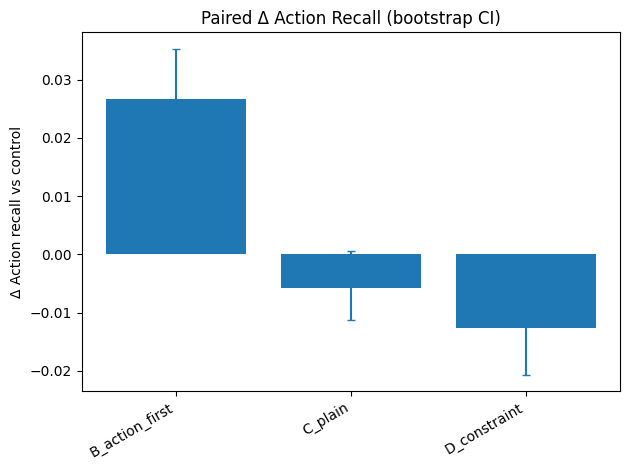

In [9]:
delta_tbl = pd.DataFrame(delta_rows).sort_values("delta_recall_mean", ascending=False)
print("\nPaired deltas vs control:")
display(delta_tbl)

# ---- Figure: delta recall with CI
if len(delta_tbl) > 0:
    x = np.arange(len(delta_tbl))
    y = delta_tbl["delta_recall_mean"].values
    yerr = np.vstack([
        y - delta_tbl["delta_recall_ci_lo"].values,
        delta_tbl["delta_recall_ci_hi"].values - y
    ])
    plt.figure()
    plt.bar(x, y)
    plt.errorbar(x, y, yerr=yerr, fmt="none", capsize=3)
    plt.xticks(x, delta_tbl["variant_id"].values, rotation=30, ha="right")
    plt.ylabel("Δ Action recall vs control")
    plt.title("Paired Δ Action Recall (bootstrap CI)")
    plt.tight_layout()
    plt.show()


In [10]:
# =========================
# 4) Win rate across alerts (robustness)
# =========================
alert_level = df.groupby(["alert_id", "variant_id"]).agg(
    mean_recall=("action_recall", "mean"),
    mean_confused=("confused", "mean"),
    mean_compliance=("compliance_intent", "mean"),
    parse_success_rate=("parse_success", "mean"),
).reset_index()

# Best recall per alert
best_recall = alert_level.sort_values(["alert_id", "mean_recall"], ascending=[True, False]).groupby("alert_id").head(1)
win_rate = best_recall["variant_id"].value_counts().rename_axis("variant_id").reset_index(name="alerts_won")
win_rate["win_rate"] = win_rate["alerts_won"] / best_recall["alert_id"].nunique()

print("\nWin rate (best mean recall per alert):")
display(win_rate)

# Optional: best (lowest) confusion per alert
best_conf = alert_level.sort_values(["alert_id", "mean_confused"], ascending=[True, True]).groupby("alert_id").head(1)
win_conf = best_conf["variant_id"].value_counts().rename_axis("variant_id").reset_index(name="alerts_won_lowest_confused")
win_conf["win_rate"] = win_conf["alerts_won_lowest_confused"] / best_conf["alert_id"].nunique()
print("\nWin rate (lowest confusion per alert):")
display(win_conf)


Win rate (best mean recall per alert):


,variant_id,alerts_won,win_rate
0,A_control,11,0.647059
1,B_action_first,4,0.235294
2,D_constraint,1,0.058824
3,C_plain,1,0.058824



Win rate (lowest confusion per alert):


,variant_id,alerts_won_lowest_confused,win_rate
0,A_control,7,0.411765
1,D_constraint,4,0.235294
2,B_action_first,3,0.176471
3,C_plain,3,0.176471


In [11]:
# =========================
# 5) Hallucinated / unsafe action checks
# =========================
# Requires ALERTS with required_actions and (optionally) alert text.
# Build map: alert_id -> required_actions
required_map = None
try:
    required_map = {a["alert_id"]: a.get("required_actions", []) for a in ALERTS}
except Exception:
    print("NOTE: ALERTS not found. Unsafe/hallucinated action checks will be skipped.")

# Simple normalization
def norm(s):
    return re.sub(r"\s+", " ", str(s).strip().lower())

# A small blacklist of clearly unsafe behaviors (edit to match your hazard domain)
UNSAFE_PHRASES = [
    "ignore evacuation", "do nothing", "stay outside",
    "drive through", "go toward the fire", "open windows",
    "drink tap water", "stop boiling", "leave shelter",
]

def count_extra_actions(actions, required_actions):
    """Count actions that don't match any required action substring (rough)."""
    if not isinstance(actions, list):
        return np.nan
    req = [norm(r) for r in (required_actions or [])]
    extras = 0
    for a in actions:
        a_n = norm(a)
        if not a_n:
            continue
        # if it matches none of the required actions (substring heuristic), count as extra
        if len(req) > 0 and not any(r in a_n or a_n in r for r in req):
            extras += 1
    return extras

NOTE: ALERTS not found. Unsafe/hallucinated action checks will be skipped.


In [12]:
def unsafe_flag(actions):
    if not isinstance(actions, list):
        return False
    joined = " ".join([norm(x) for x in actions])
    return any(p in joined for p in UNSAFE_PHRASES)

if required_map is not None:
    df["required_actions"] = df["alert_id"].map(required_map)
    df["extra_actions_count"] = df.apply(lambda r: count_extra_actions(r["actions_list"], r["required_actions"]), axis=1)
    df["unsafe_flag"] = df["actions_list"].apply(unsafe_flag)

    unsafe_tbl = df.groupby("variant_id").agg(
        unsafe_rate=("unsafe_flag", "mean"),
        mean_extra_actions=("extra_actions_count", "mean"),
    ).reset_index().sort_values("unsafe_rate", ascending=False)

    print("\nUnsafe / extra action diagnostics:")
    display(unsafe_tbl)


In [13]:
# =========================
# 6) Failure-mode taxonomy from confusion_reason / needs_info
# =========================
def categorize_failure(reason, needs):
    txt = norm(reason) + " " + " ".join([norm(x) for x in (needs if isinstance(needs, list) else [])])
    if not txt.strip():
        return "none_reported"

    rules = [
        ("missing_location", ["where", "location", "area", "address", "which part"]),
        ("missing_timing", ["until when", "when", "time", "duration", "how long", "deadline"]),
        ("unclear_action_steps", ["what do i do", "steps", "how to", "instructions", "unclear", "not sure what"]),
        ("conflicting_info", ["conflict", "contradict", "both", "but also"]),
        ("jargon_or_terms", ["shelter in place", "advisory", "alert level", "acronym", "jargon"]),
        ("resource_constraints", ["no car", "cannot", "don't have", "no access", "childcare", "disabled"]),
        ("update_channel_unclear", ["where to check", "updates", "website", "link", "official"]),
    ]
    for label, kws in rules:
        if any(k in txt for k in kws):
            return label
    return "other"

df["failure_mode"] = df.apply(lambda r: categorize_failure(r["confusion_reason"], r["needs_info"]), axis=1)

failure_tbl = df.groupby(["variant_id", "failure_mode"]).size().reset_index(name="count")
failure_tbl["share"] = failure_tbl.groupby("variant_id")["count"].transform(lambda x: x / x.sum())

print("\nFailure mode distribution (top rows):")
display(failure_tbl.sort_values(["variant_id", "count"], ascending=[True, False]).head(30))


Failure mode distribution (top rows):


,variant_id,failure_mode,count,share
2,A_control,missing_timing,392,0.288235
4,A_control,other,364,0.267647
1,A_control,missing_location,228,0.167647
6,A_control,unclear_action_steps,199,0.146324
3,A_control,none_reported,139,0.102206
7,A_control,update_channel_unclear,21,0.015441
5,A_control,resource_constraints,15,0.011029
0,A_control,jargon_or_terms,2,0.001471
11,B_action_first,other,460,0.338235
9,B_action_first,missing_timing,264,0.194118


In [24]:
# =========================
# 7) Message feature analysis
# =========================
# Build message text for each (alert_id, variant_id)
# Requires ALERTS + variants_from_alert. If you don't have them here, you can still do features
# only if your df already includes a column like 'variant_text'.
variant_text_col = next((c for c in ["variant_text", "message_text", "alert_variant_text"] if c in df.columns), None)

variant_text_df = None
if variant_text_col:
    variant_text_df = df[["alert_id", "variant_id", variant_text_col]].drop_duplicates().rename(columns={variant_text_col:"variant_text"})
else:
    try:
        rows = []
        for a in ALERTS:
            vmap = variants_from_alert(a["text"])
            for vid, vtxt in vmap.items():
                rows.append({"alert_id": a["alert_id"], "variant_id": vid, "variant_text": vtxt})
        variant_text_df = pd.DataFrame(rows)
    except Exception:
        print("NOTE: No variant text available. Add 'variant_text' to results or provide ALERTS+variants_from_alert.")


In [15]:
# --- Feature functions
def count_syllables(word):
    word = re.sub(r"[^a-z]", "", word.lower())
    if not word:
        return 0
    vowels = "aeiouy"
    count = 0
    prev_vowel = False
    for ch in word:
        is_vowel = ch in vowels
        if is_vowel and not prev_vowel:
            count += 1
        prev_vowel = is_vowel
    if word.endswith("e") and count > 1:
        count -= 1
    return max(count, 1)

def flesch_kincaid_grade(text):
    # Simple heuristic FK grade
    text = str(text)
    sentences = re.split(r"[.!?]+", text)
    sentences = [s.strip() for s in sentences if s.strip()]
    words = re.findall(r"\b[\w']+\b", text.lower())
    if len(sentences) == 0 or len(words) == 0:
        return np.nan
    sylls = sum(count_syllables(w) for w in words)
    wps = len(words) / len(sentences)
    spw = sylls / len(words)
    return 0.39 * wps + 11.8 * spw - 15.59

In [16]:
def message_features(text):
    t = str(text)
    words = re.findall(r"\b[\w']+\b", t)
    lines = t.splitlines()
    sentences = [s for s in re.split(r"[.!?]+", t) if s.strip()]
    bullet_lines = [ln for ln in lines if ln.strip().startswith(("-", "•", "*"))]

    # slot heuristics
    has_time = bool(re.search(r"\b(today|tonight|tomorrow|until|am|pm|\d{1,2}:\d{2})\b", t.lower()))
    has_location = bool(re.search(r"\b(near|in|at|between|area|county|city|neighborhood|mile)\b", t.lower()))
    has_source = bool(re.search(r"\b(official|police|sheriff|fire department|emergency management|national weather service|nws)\b", t.lower()))
    has_url = bool(re.search(r"https?://|www\.", t.lower()))

    return {
        "char_len": len(t),
        "word_len": len(words),
        "sentence_count": len(sentences),
        "avg_words_per_sentence": (len(words)/len(sentences)) if len(sentences) else np.nan,
        "line_count": len(lines),
        "bullet_count": len(bullet_lines),
        "fk_grade": flesch_kincaid_grade(t),
        "has_time": has_time,
        "has_location": has_location,
        "has_source": has_source,
        "has_url": has_url,
    }

In [18]:
variant_text_df


Feature + outcome merged:


,alert_id,variant_id,mean_recall,mean_confused,mean_compliance,parse_success_rate,n,variant_text,char_len,word_len,sentence_count,avg_words_per_sentence,line_count,bullet_count,fk_grade,has_time,has_location,has_source,has_url
0,a1,A_control,0.666667,0.250,0.82500,1.0,80,Boil water before drinking or cooking until fu...,126,19,3,6.333333,1,0,8.616842,True,False,True,False
1,a1,B_action_first,0.666667,0.250,0.95000,1.0,80,DO THIS NOW:\n- Follow the safety actions list...,244,37,5,7.400000,6,2,8.982486,True,False,True,False
2,a1,C_plain,0.666667,0.250,0.82500,1.0,80,Important safety message:\nBoil water before d...,152,22,3,7.333333,2,0,10.333636,True,False,True,False
3,a1,D_constraint,0.666667,0.250,0.83875,1.0,80,Boil water before drinking or cooking until fu...,282,48,6,8.000000,3,0,5.967500,True,False,True,False
4,a10,A_control,0.393750,0.175,0.84750,1.0,80,"Sub-freezing temperatures are possible, which ...",259,36,3,12.000000,1,0,9.740000,False,False,False,False



Correlation table (features vs outcomes):


,mean_recall,mean_confused,mean_compliance
char_len,-0.180084,-0.039584,0.223128
word_len,-0.182533,-0.070316,0.201860
avg_words_per_sentence,-0.709927,0.152724,-0.155356
bullet_count,0.056237,0.040630,0.456774
fk_grade,-0.203681,0.307589,-0.152692


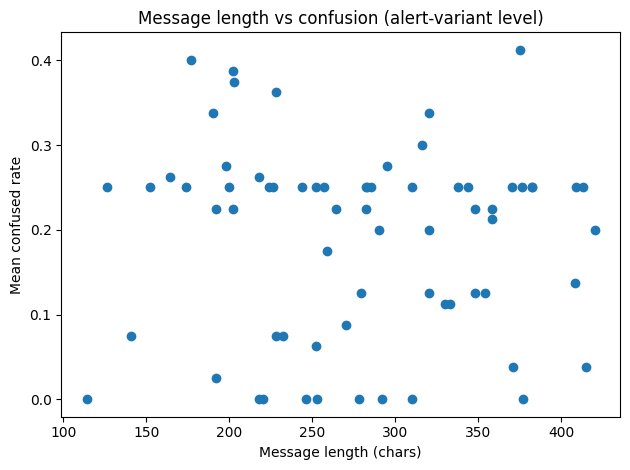

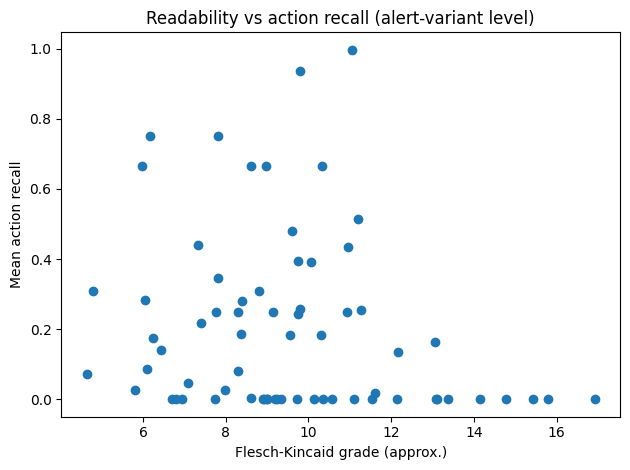


Saved CSVs to current working dir (Colab).


In [25]:
if variant_text_df is not None:
    feats = variant_text_df.copy()
    feat_cols = feats["variant_text"].apply(message_features).apply(pd.Series)
    feats = pd.concat([feats, feat_cols], axis=1)

    # Merge with alert-level outcomes
    outcomes = df.groupby(["alert_id", "variant_id"]).agg(
        mean_recall=("action_recall", "mean"),
        mean_confused=("confused", "mean"),
        mean_compliance=("compliance_intent", "mean"),
        parse_success_rate=("parse_success", "mean"),
        n=("agent_id", "count"),
    ).reset_index()

    feat_out = outcomes.merge(feats, on=["alert_id", "variant_id"], how="left")
    print("\nFeature + outcome merged:")
    display(feat_out.head())

    # Correlations (numeric features only)
    num_feats = ["char_len","word_len","avg_words_per_sentence","bullet_count","fk_grade"]
    corr_tbl = feat_out[num_feats + ["mean_recall","mean_confused","mean_compliance"]].corr(numeric_only=True)
    print("\nCorrelation table (features vs outcomes):")
    display(corr_tbl.loc[num_feats, ["mean_recall","mean_confused","mean_compliance"]])

    # ---- Scatter: char_len vs confusion
    plt.figure()
    plt.scatter(feat_out["char_len"], feat_out["mean_confused"])
    plt.xlabel("Message length (chars)")
    plt.ylabel("Mean confused rate")
    plt.title("Message length vs confusion (alert-variant level)")
    plt.tight_layout()
    plt.show()

    # ---- Scatter: fk_grade vs recall
    plt.figure()
    plt.scatter(feat_out["fk_grade"], feat_out["mean_recall"])
    plt.xlabel("Flesch-Kincaid grade (approx.)")
    plt.ylabel("Mean action recall")
    plt.title("Readability vs action recall (alert-variant level)")
    plt.tight_layout()
    plt.show()

    # Save tables
    diag.to_csv("diag_by_variant.csv", index=False)
    perf.to_csv("perf_by_variant.csv", index=False)
    delta_tbl.to_csv("paired_deltas_vs_control.csv", index=False)
    win_rate.to_csv("win_rate_by_alert.csv", index=False)
    failure_tbl.to_csv("failure_modes_by_variant.csv", index=False)
    feat_out.to_csv("message_features_with_outcomes.csv", index=False)
    print("\nSaved CSVs to current working dir (Colab).")

,alert_id,variant_id,mean_recall,mean_confused,mean_compliance,parse_success_rate,n,variant_text,char_len,word_len,...,has_source_ctrl,has_url_ctrl,d_mean_recall,d_mean_confused,d_mean_compliance,d_char_len,d_word_len,d_avg_words_per_sentence,d_bullet_count,d_fk_grade
0,a1,B_action_first,0.666667,0.25,0.95000,1.0,80,DO THIS NOW:\n- Follow the safety actions list...,244,37,...,True,False,0.000000,0.000,0.12500,118,18,1.066667,2,0.365644
1,a1,C_plain,0.666667,0.25,0.82500,1.0,80,Important safety message:\nBoil water before d...,152,22,...,True,False,0.000000,0.000,0.00000,26,3,1.000000,0,1.716794
2,a1,D_constraint,0.666667,0.25,0.83875,1.0,80,Boil water before drinking or cooking until fu...,282,48,...,True,False,0.000000,0.000,0.01375,156,29,1.666667,0,-2.649342
3,a10,B_action_first,0.481250,0.00,0.95000,1.0,80,DO THIS NOW:\n- Follow the safety actions list...,377,54,...,False,False,0.087500,-0.175,0.10250,118,18,-1.200000,2,-0.140222
4,a10,C_plain,0.434375,0.25,0.82000,1.0,80,Important safety message:\nSub-freezing temper...,285,39,...,False,False,0.040625,0.075,-0.02750,26,3,1.000000,0,1.222051


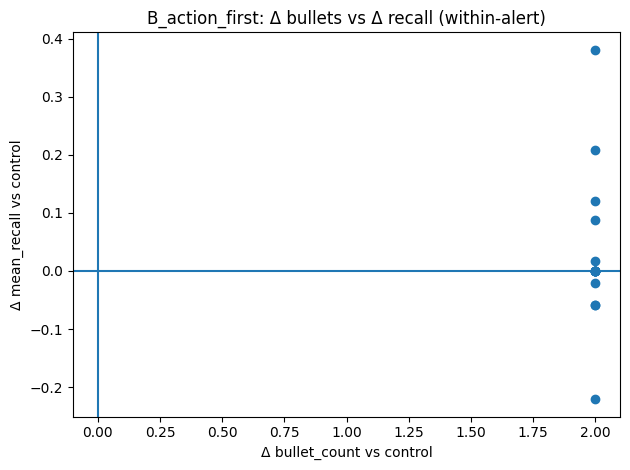

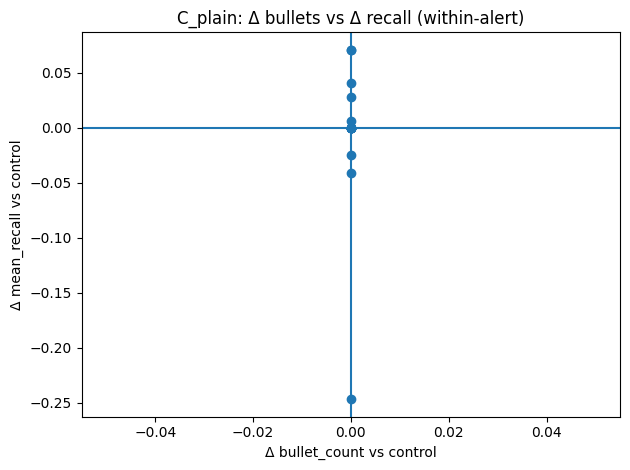

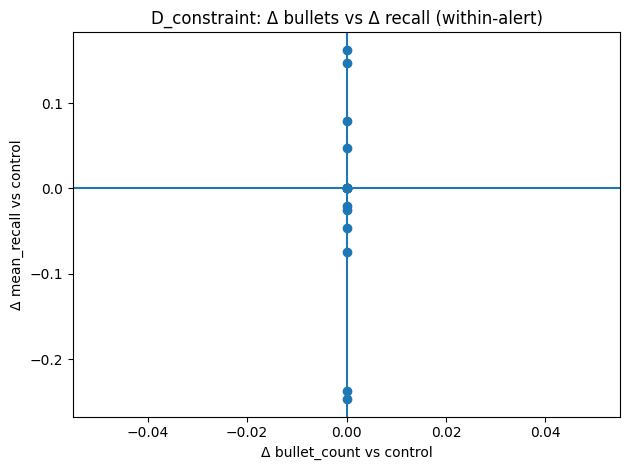

,d_mean_recall,d_mean_confused,d_mean_compliance
d_char_len,0.010690,-0.057003,0.272502
d_avg_words_per_sentence,-0.053899,0.207459,-0.327713
d_bullet_count,0.166743,0.053675,0.579807
d_fk_grade,0.045617,0.238251,-0.139911


In [27]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

# alert-variant level table (one row per alert_id, variant_id)
av = feat_out.copy()  # from your earlier merge
CONTROL_ID = "A_control"

# split control vs others and compute deltas within alert
ctrl = av[av["variant_id"] == CONTROL_ID].set_index("alert_id")
others = av[av["variant_id"] != CONTROL_ID].set_index(["alert_id","variant_id"])

# join control features/outcomes onto others
j = others.join(ctrl, on="alert_id", rsuffix="_ctrl")

# deltas (features + outcomes)
for col in ["mean_recall","mean_confused","mean_compliance"]:
    j[f"d_{col}"] = j[col] - j[f"{col}_ctrl"]

for col in ["char_len","word_len","avg_words_per_sentence","bullet_count","fk_grade"]:
    j[f"d_{col}"] = j[col] - j[f"{col}_ctrl"]

# Fix: Ensure 'variant_id' is not a column before resetting the index
# It should be an index level, but the error suggests it's also a column.
if 'variant_id' in j.columns:
    j = j.drop(columns=['variant_id'])

deltas = j.reset_index()
display(deltas.head())

# Scatter: Δbullet_count vs Δrecall, colored by variant
for vid in deltas["variant_id"].unique():
    sub = deltas[deltas["variant_id"] == vid]
    plt.figure()
    plt.scatter(sub["d_bullet_count"], sub["d_mean_recall"])
    plt.axhline(0); plt.axvline(0)
    plt.xlabel("Δ bullet_count vs control")
    plt.ylabel("Δ mean_recall vs control")
    plt.title(f"{vid}: Δ bullets vs Δ recall (within-alert)")
    plt.tight_layout()
    plt.show()

# Quick correlation table on deltas (overall)
delta_corr = deltas[[f"d_{c}" for c in ["char_len","avg_words_per_sentence","bullet_count","fk_grade",
                                       "mean_recall","mean_confused","mean_compliance"]]].corr()
display(delta_corr.loc[[f"d_{c}" for c in ["char_len","avg_words_per_sentence","bullet_count","fk_grade"]],
                       [f"d_{c}" for c in ["mean_recall","mean_confused","mean_compliance"]]])

In [28]:
import statsmodels.formula.api as smf

# Use alert-variant table (feat_out)
dat = feat_out.dropna(subset=["mean_recall","char_len","bullet_count","fk_grade"]).copy()

# OLS with alert fixed effects
m1 = smf.ols("mean_recall ~ bullet_count + fk_grade + char_len + C(alert_id)", data=dat).fit()
print(m1.summary())

# If you want variant category controlled too:
m2 = smf.ols("mean_recall ~ bullet_count + fk_grade + char_len + C(alert_id) + C(variant_id)", data=dat).fit()
print(m2.summary())


                            OLS Regression Results                            
Dep. Variable:            mean_recall   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.926
Method:                 Least Squares   F-statistic:                     45.37
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           2.82e-24
Time:                        07:20:07   Log-Likelihood:                 97.037
No. Observations:                  68   AIC:                            -154.1
Df Residuals:                      48   BIC:                            -109.7
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.7116      0

In [29]:
import re, numpy as np

ACTION_VERBS = r"(evacuate|leave|avoid|stay|shelter|boil|seek|call|move|close|turn off|do not|don't)"
def early_action_score(text, window=160):
    t = str(text).lower()
    head = t[:window]
    return 1 if re.search(ACTION_VERBS, head) else 0

def slot_features(text):
    t = str(text).lower()
    has_time = bool(re.search(r"\b(today|tonight|tomorrow|until|am|pm|\d{1,2}:\d{2})\b", t))
    has_location = bool(re.search(r"\b(in|at|near|between|area|county|city|neighborhood)\b", t))
    has_source = bool(re.search(r"\b(police|sheriff|fire department|emergency management|national weather service|nws|official)\b", t))
    has_guidance = bool(re.search(ACTION_VERBS, t))
    return has_time, has_location, has_source, has_guidance

# add to feats dataframe you built from variant_text_df
feats["early_action"] = feats["variant_text"].apply(early_action_score)
tmp = feats["variant_text"].apply(lambda x: slot_features(x)).apply(pd.Series)
tmp.columns = ["has_time","has_location","has_source","has_guidance"]
feats = pd.concat([feats, tmp], axis=1)
feats["slot_count"] = feats[["has_time","has_location","has_source","has_guidance"]].sum(axis=1)

# merge again (or merge these columns into feat_out)
feat_out2 = outcomes.merge(feats, on=["alert_id","variant_id"], how="left")

# now run fixed effects regression with these
import statsmodels.formula.api as smf
dat = feat_out2.dropna(subset=["mean_recall","early_action","slot_count"]).copy()
m = smf.ols("mean_recall ~ early_action + slot_count + bullet_count + C(alert_id)", data=dat).fit()
print(m.summary())


                            OLS Regression Results                            
Dep. Variable:            mean_recall   R-squared:                       0.948
Model:                            OLS   Adj. R-squared:                  0.927
Method:                 Least Squares   F-statistic:                     45.77
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           2.32e-24
Time:                        07:21:08   Log-Likelihood:                 97.317
No. Observations:                  68   AIC:                            -154.6
Df Residuals:                      48   BIC:                            -110.2
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.6911      0

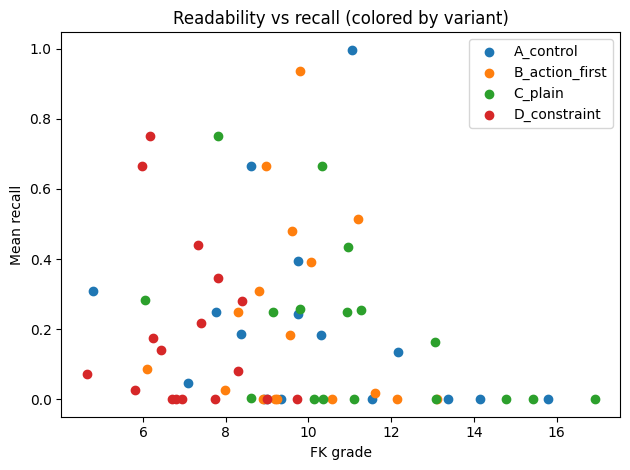

In [30]:
plt.figure()
for vid in feat_out["variant_id"].unique():
    sub = feat_out[feat_out["variant_id"] == vid]
    plt.scatter(sub["fk_grade"], sub["mean_recall"], label=vid)
plt.xlabel("FK grade"); plt.ylabel("Mean recall")
plt.title("Readability vs recall (colored by variant)")
plt.legend()
plt.tight_layout()
plt.show()


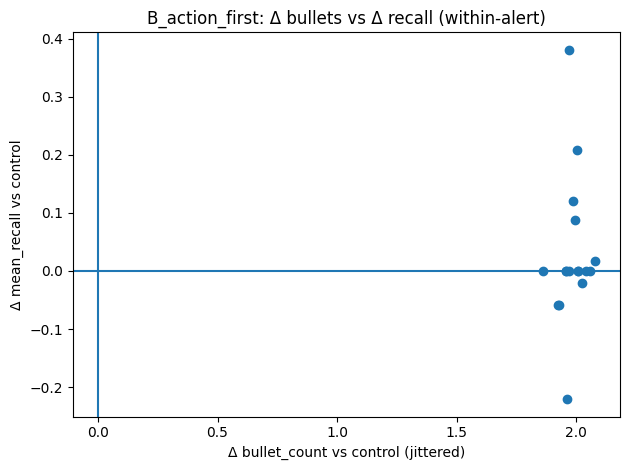

In [31]:
import numpy as np, matplotlib.pyplot as plt

def jitter(x, scale=0.06, seed=0):
    rng = np.random.default_rng(seed)
    return x + rng.normal(0, scale, size=len(x))

sub = deltas[deltas["variant_id"] == "B_action_first"].copy()
x = sub["d_bullet_count"].fillna(0).astype(float).values
y = sub["d_mean_recall"].astype(float).values

plt.figure()
plt.scatter(jitter(x), y)
plt.axhline(0); plt.axvline(0)
plt.xlabel("Δ bullet_count vs control (jittered)")
plt.ylabel("Δ mean_recall vs control")
plt.title("B_action_first: Δ bullets vs Δ recall (within-alert)")
plt.tight_layout()
plt.show()


/tmp/ipython-input-3278108500.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=[str(k) for k in sorted(sub["d_bullet_count"].unique())])


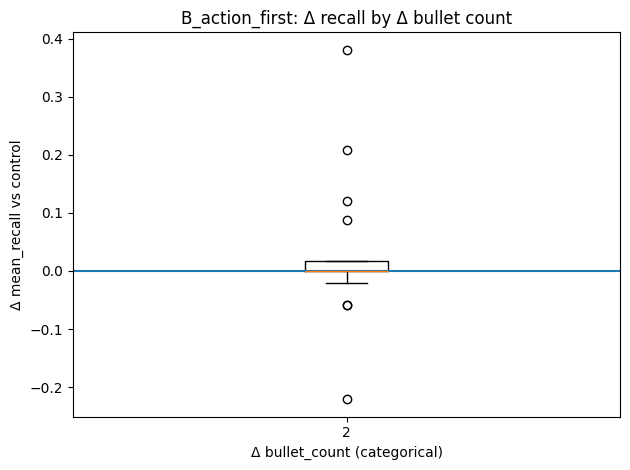

In [32]:
sub = deltas[deltas["variant_id"] == "B_action_first"].copy()
sub["d_bullet_count"] = sub["d_bullet_count"].fillna(0).astype(int)

groups = [g["d_mean_recall"].dropna().values for _, g in sub.groupby("d_bullet_count")]

plt.figure()
plt.boxplot(groups, labels=[str(k) for k in sorted(sub["d_bullet_count"].unique())])
plt.axhline(0)
plt.xlabel("Δ bullet_count (categorical)")
plt.ylabel("Δ mean_recall vs control")
plt.title("B_action_first: Δ recall by Δ bullet count")
plt.tight_layout()
plt.show()


In [33]:
import re, numpy as np

ACTION_VERBS = r"\b(evacuate|leave|avoid|stay|shelter|boil|seek|call|move|close|turn off|do not|don't)\b"

def first_action_pos(text):
    t = str(text).lower()
    m = re.search(ACTION_VERBS, t)
    return m.start() if m else np.nan

def early_action_ratio(text):
    pos = first_action_pos(text)
    if np.isnan(pos):
        return np.nan
    return pos / max(len(str(text)), 1)

feats["first_action_pos"] = feats["variant_text"].apply(first_action_pos)
feats["early_action_ratio"] = feats["variant_text"].apply(early_action_ratio)

feat_out3 = outcomes.merge(feats, on=["alert_id","variant_id"], how="left")


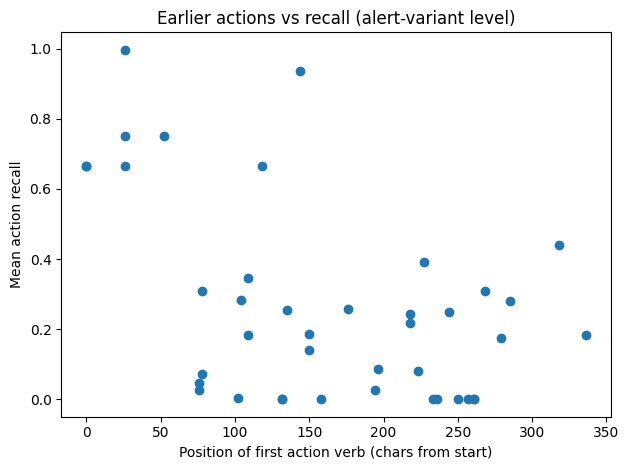

In [34]:
plt.figure()
plt.scatter(feat_out3["first_action_pos"], feat_out3["mean_recall"])
plt.xlabel("Position of first action verb (chars from start)")
plt.ylabel("Mean action recall")
plt.title("Earlier actions vs recall (alert-variant level)")
plt.tight_layout()
plt.show()


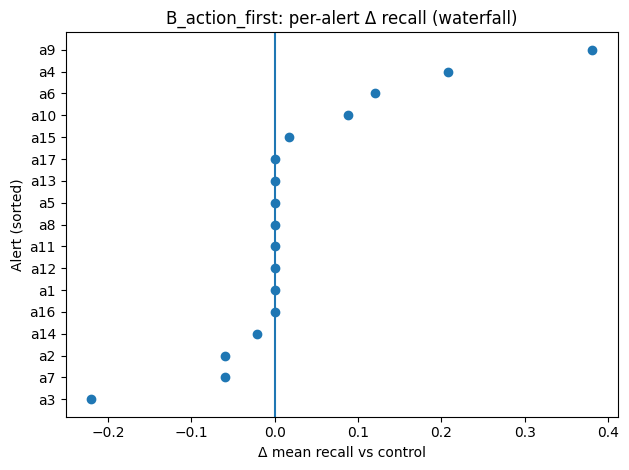

n alerts: 17 | improved: 5 | harmed: 4 | unchanged: 8 | median Δ: 0.0


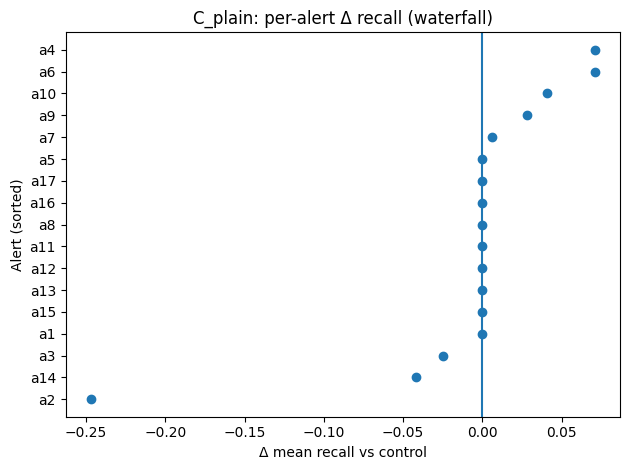

n alerts: 17 | improved: 5 | harmed: 3 | unchanged: 9 | median Δ: 0.0


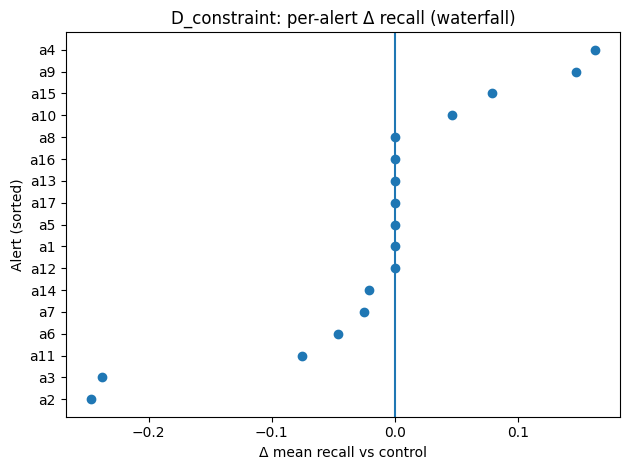

n alerts: 17 | improved: 4 | harmed: 6 | unchanged: 7 | median Δ: 0.0


In [36]:
import numpy as np, matplotlib.pyplot as plt

# deltas: DataFrame with columns ['alert_id','variant_id','d_mean_recall'] from your within-alert join
def plot_waterfall(deltas, variant_id, metric="d_mean_recall"):
    sub = deltas[deltas["variant_id"] == variant_id].copy()
    sub = sub.dropna(subset=[metric])

    sub = sub.sort_values(metric).reset_index(drop=True)
    x = sub[metric].values
    y = np.arange(len(sub))

    plt.figure()
    plt.scatter(x, y)
    plt.axvline(0)
    plt.yticks(y, sub["alert_id"].astype(str))
    plt.xlabel("Δ mean recall vs control")
    plt.ylabel("Alert (sorted)")
    plt.title(f"{variant_id}: per-alert Δ recall (waterfall)")
    plt.tight_layout()
    plt.show()

    # quick summary text (optional)
    print("n alerts:", len(sub),
          "| improved:", int((x > 0).sum()),
          "| harmed:", int((x < 0).sum()),
          "| unchanged:", int((x == 0).sum()),
          "| median Δ:", float(np.median(x)))

plot_waterfall(deltas, "B_action_first")
plot_waterfall(deltas, "C_plain")
plot_waterfall(deltas, "D_constraint")


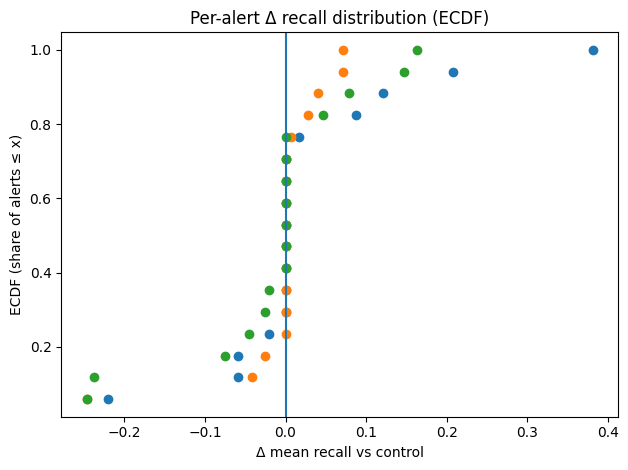

In [37]:
def ecdf(vals):
    v = np.sort(np.asarray(vals))
    y = np.arange(1, len(v)+1) / len(v)
    return v, y

plt.figure()
for vid in sorted(deltas["variant_id"].unique()):
    sub = deltas[deltas["variant_id"] == vid]["d_mean_recall"].dropna().values
    if len(sub) == 0:
        continue
    x, y = ecdf(sub)
    plt.plot(x, y, marker='o', linestyle='none')  # points only
plt.axvline(0)
plt.xlabel("Δ mean recall vs control")
plt.ylabel("ECDF (share of alerts ≤ x)")
plt.title("Per-alert Δ recall distribution (ECDF)")
plt.tight_layout()
plt.show()


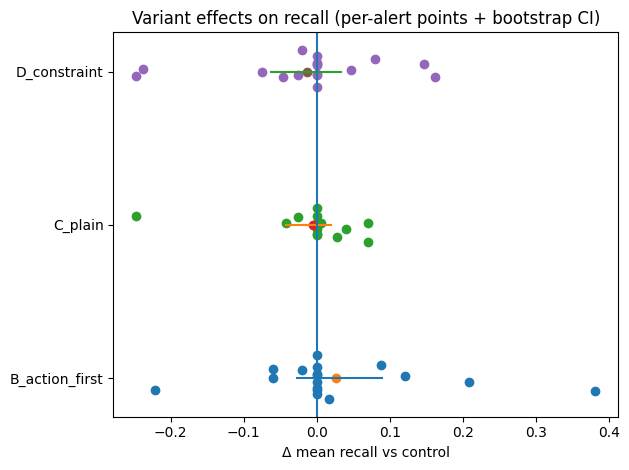

In [38]:
import numpy as np, matplotlib.pyplot as plt

def bootstrap_ci(arr, n_boot=4000, alpha=0.05, seed=0):
    rng = np.random.default_rng(seed)
    v = np.asarray(arr, dtype=float)
    v = v[~np.isnan(v)]
    if len(v) == 0:
        return np.nan, np.nan, np.nan
    boots = np.array([rng.choice(v, size=len(v), replace=True).mean() for _ in range(n_boot)])
    return v.mean(), np.quantile(boots, alpha/2), np.quantile(boots, 1-alpha/2)

rows = []
for vid in sorted(deltas["variant_id"].unique()):
    x = deltas.loc[deltas["variant_id"] == vid, "d_mean_recall"].dropna().values
    m, lo, hi = bootstrap_ci(x, seed=1)
    rows.append((vid, x, m, lo, hi))

plt.figure()
for i, (vid, x, m, lo, hi) in enumerate(rows):
    # jittered raw points
    y = np.full_like(x, i, dtype=float) + np.random.normal(0, 0.06, size=len(x))
    plt.scatter(x, y)

    # CI line + mean marker
    plt.plot([lo, hi], [i, i])
    plt.scatter([m], [i])

plt.axvline(0)
plt.yticks(range(len(rows)), [r[0] for r in rows])
plt.xlabel("Δ mean recall vs control")
plt.title("Variant effects on recall (per-alert points + bootstrap CI)")
plt.tight_layout()
plt.show()


Columns in j: ['alert_id', 'variant_id', 'mean_recall', 'mean_confused', 'mean_compliance', 'parse_success_rate', 'n', 'variant_text', 'char_len', 'word_len', 'sentence_count', 'avg_words_per_sentence', 'line_count', 'bullet_count', 'fk_grade', 'has_time', 'has_location', 'has_source', 'has_url', 'first_action_pos', 'mean_recall_ctrl', 'first_action_pos_ctrl', 'd_mean_recall', 'd_first_action_pos']


,alert_id,variant_id,d_first_action_pos,d_mean_recall
0,a1,B_action_first,118.0,0.000000
1,a1,C_plain,26.0,0.000000
2,a1,D_constraint,0.0,0.000000
3,a10,B_action_first,NaN,0.087500
4,a10,C_plain,NaN,0.040625


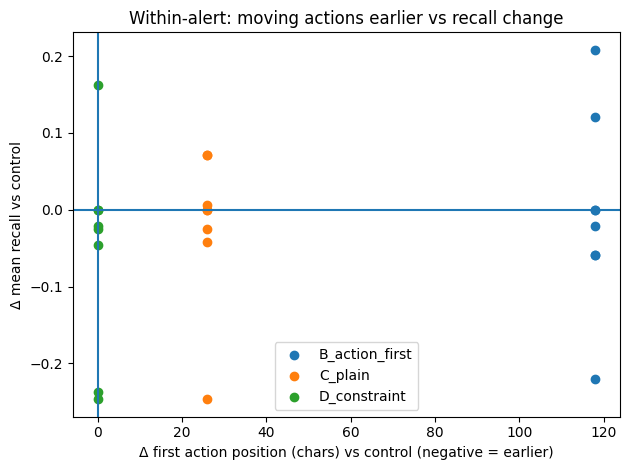

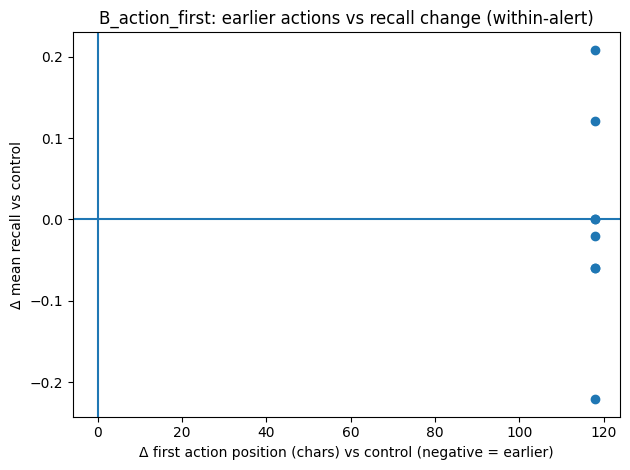

In [40]:
import re, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# 1) Define what counts as an "action verb" (tweak as needed)
ACTION_RE = re.compile(
    r"\b(evacuate|leave|avoid|stay|shelter|boil|seek|call|move|close|turn off|do not|don't)\b",
    flags=re.IGNORECASE
)

def first_action_pos(text):
    if text is None:
        return np.nan
    t = str(text)
    m = ACTION_RE.search(t)
    return float(m.start()) if m else np.nan

# 2) Get message text per alert/variant
# You should have variant_text either in feat_out already or in feats/variant_text_df.
if "variant_text" in feat_out.columns:
    text_df = feat_out[["alert_id","variant_id","variant_text"]].drop_duplicates()
elif "variant_text" in feats.columns:
    text_df = feats[["alert_id","variant_id","variant_text"]].drop_duplicates()
else:
    raise ValueError("No 'variant_text' found in feat_out or feats. Add it first.")

text_df["first_action_pos"] = text_df["variant_text"].apply(first_action_pos)

# 3) Merge into alert-variant outcomes
# feat_out should already have mean_recall per (alert_id, variant_id)
av = feat_out.merge(
    text_df[["alert_id","variant_id","first_action_pos"]],
    on=["alert_id","variant_id"],
    how="left"
)

CONTROL_ID = "A_control"

ctrl = av[av["variant_id"] == CONTROL_ID].set_index("alert_id")
oth  = av[av["variant_id"] != CONTROL_ID].set_index(["alert_id","variant_id"])

j = oth.join(ctrl[["mean_recall","first_action_pos"]], on="alert_id", rsuffix="_ctrl").reset_index()

j["d_mean_recall"] = j["mean_recall"] - j["mean_recall_ctrl"]
j["d_first_action_pos"] = j["first_action_pos"] - j["first_action_pos_ctrl"]

print("Columns in j:", j.columns.tolist())
display(j[["alert_id","variant_id","d_first_action_pos","d_mean_recall"]].head())

# 4) Plot: all variants together (jitter by variant)
plt.figure()
for vid in sorted(j["variant_id"].unique()):
    sub = j[j["variant_id"] == vid]
    plt.scatter(sub["d_first_action_pos"], sub["d_mean_recall"], label=vid)
plt.axhline(0); plt.axvline(0)
plt.xlabel("Δ first action position (chars) vs control (negative = earlier)")
plt.ylabel("Δ mean recall vs control")
plt.title("Within-alert: moving actions earlier vs recall change")
plt.legend()
plt.tight_layout()
plt.show()

# 5) Plot: B_action_first only (often clearest)
if "B_action_first" in j["variant_id"].unique():
    sub = j[j["variant_id"] == "B_action_first"].dropna(subset=["d_first_action_pos","d_mean_recall"])
    plt.figure()
    plt.scatter(sub["d_first_action_pos"], sub["d_mean_recall"])
    plt.axhline(0); plt.axvline(0)
    plt.xlabel("Δ first action position (chars) vs control (negative = earlier)")
    plt.ylabel("Δ mean recall vs control")
    plt.title("B_action_first: earlier actions vs recall change (within-alert)")
    plt.tight_layout()
    plt.show()


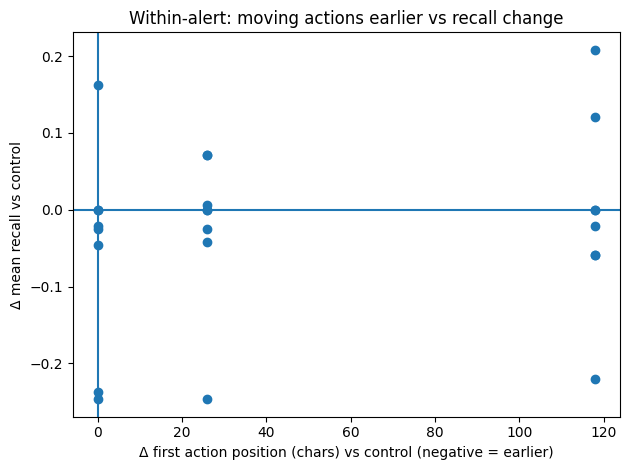

In [41]:
# Assuming you created j with d_first_action_pos and d_mean_recall (from my earlier snippet)
plt.figure()
plt.scatter(j["d_first_action_pos"], j["d_mean_recall"])
plt.axhline(0); plt.axvline(0)
plt.xlabel("Δ first action position (chars) vs control (negative = earlier)")
plt.ylabel("Δ mean recall vs control")
plt.title("Within-alert: moving actions earlier vs recall change")
plt.tight_layout()
plt.show()
